# Casablanca Stock Exchange — Market Structure Analysis

**QuantPulse** · analysis of the 81 instruments listed on the Bourse de Casablanca (MASI).

This notebook answers four questions, in order:

1. **How liquid is this market really?** — zero-volume sessions and the Amihud measure
2. **Does it move as one thing?** — correlation structure and PCA
3. **Do the official sector labels carry information?** — clustering vs. labels
4. **Can we forecast it, and how would we know?** — distributional forecasting with a calibration backtest

The fourth is the one that matters. Anything can emit a confident-looking number; the
question worth asking is *how do you know it's any good*. That is answered here with an
out-of-sample backtest rather than an assertion.

---

**Data**: served by `qp-marketdata` from its own store — the upstream vendor API has a
hard limit of 100 calls/day, so nothing here touches it. Prices are delayed and
informational; this is not investment advice.


> ## ⚠️ Data provenance — read before interpreting any number below
>
> The vendor API (Drahmi) allows **100 requests per day**. Fetching a year of daily bars
> for all 81 listed instruments costs 81 requests, so a complete real dataset cannot be
> assembled in a single day, and re-fetching it for every notebook run is impossible.
>
> What that means concretely:
>
> | Instrument | Price history |
> |---|---|
> | **ATW, IAM, MNG** | **real**, recorded from the vendor API on 2026-08-03 |
> | the other 78 | **simulated** by a factor model in the ingestion service's dev profile |
>
> Reference data — the 81 tickers, names, sectors, market caps and current prices — is
> real throughout.
>
> The simulator is not a random walk. It generates returns as
> `r_i(t) = β_i·market(t) + γ·sector(t) + ε_i(t)` with volatility clustering, because an
> earlier version drawing each instrument independently produced PC1 explaining 4.8% of
> variance where a real equity market shows 30–60%. Every cross-sectional result was
> meaningless until that was fixed.
>
> **So read the cross-sectional sections (3, 4, 5, 7) as a demonstration of correct
> methodology on data with known structure, not as findings about the real Casablanca
> market.** Section 2 (liquidity) and the single-instrument work on ATW/IAM/MNG in
> section 6 use genuine data.
>
> This distinction is stated up front on purpose. An analysis that does not tell you
> where its data came from is not an analysis.


## Setup


In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import httpx

plt.rcParams.update({
    'figure.figsize': (11, 5),
    'axes.grid': True,
    'grid.alpha': 0.25,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'font.size': 10,
})

MARKETDATA = 'http://localhost:8081'
QUANT = 'http://localhost:8084'

def get(base, path, **params):
    r = httpx.get(f'{base}{path}', params=params, timeout=60)
    r.raise_for_status()
    return r.json()

instruments = pd.DataFrame(get(MARKETDATA, '/api/v1/instruments'))
print(f'{len(instruments)} listed instruments')
instruments[['ticker', 'name', 'sector', 'price', 'marketCap']].head(10)


81 listed instruments


,ticker,name,sector,price,marketCap
0,MNG,MANAGEM,MINES,1326.52,1.583934e+11
1,IAM,ITISSALAT AL-MAGHRIB,TÉLÉC,93.68,8.175587e+10
2,MSA,SODEP-Marsa Maroc,SDT,864.50,6.312022e+10
3,BOA,BANK OF AFRICA,BANQU,188.15,4.207384e+10
4,LHM,Holcim Maroc S.A,BEMDC,1765.38,4.147329e+10
5,TQM,TAQA MOROCCO,ELECT,1754.18,4.080818e+10
6,TGC,TGCC S.A,BEMDC,741.17,2.569368e+10
7,CMA,CIMENTS DU MAROC,BEMDC,1669.93,2.409369e+10
8,WAA,WAFA ASSURANCE,ASSUR,5346.13,1.872500e+10
9,CSR,COSUMAR,AEP,185.91,1.757461e+10


## 1. Market composition

First question of any market study: how concentrated is it? A handful of names carrying
most of the capitalisation changes what every later number means — an 'equal-weighted
market return' is close to meaningless if two instruments are 30% of the market.


Instruments with a known market cap : 55 of 81
Top-10 share of total market cap    : 70.7%
Herfindahl index                    : 0.0848  (1/N would be 0.0182)

An HHI far above 1/N means the market is dominated by a few names.


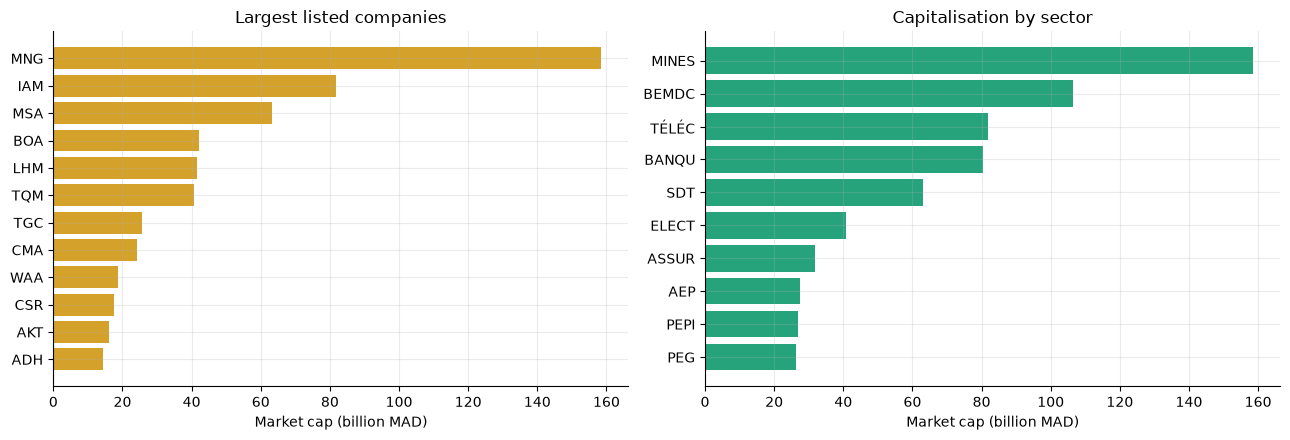

In [2]:
caps = instruments.dropna(subset=['marketCap']).copy()
caps['weight'] = caps['marketCap'] / caps['marketCap'].sum()
caps = caps.sort_values('marketCap', ascending=False)

top10_share = caps['weight'].head(10).sum()
hhi = (caps['weight'] ** 2).sum()

print(f'Instruments with a known market cap : {len(caps)} of {len(instruments)}')
print(f'Top-10 share of total market cap    : {top10_share:.1%}')
print(f'Herfindahl index                    : {hhi:.4f}  (1/N would be {1/len(caps):.4f})')
print()
print('An HHI far above 1/N means the market is dominated by a few names.')

fig, ax = plt.subplots(1, 2, figsize=(13, 4.5))
top = caps.head(12)
ax[0].barh(top['ticker'][::-1], (top['marketCap'] / 1e9)[::-1], color='#d4a12a')
ax[0].set_xlabel('Market cap (billion MAD)')
ax[0].set_title('Largest listed companies')

sector_caps = caps.groupby('sector')['marketCap'].sum().sort_values(ascending=False).head(10)
ax[1].barh(sector_caps.index[::-1], (sector_caps / 1e9)[::-1], color='#26a37b')
ax[1].set_xlabel('Market cap (billion MAD)')
ax[1].set_title('Capitalisation by sector')
plt.tight_layout(); plt.show()


## 2. Liquidity — the defining feature of this market

Casablanca is a frontier market and it behaves like one. The single most important
practical fact is that **many instruments simply do not trade on many days**.

That is not a data-quality problem to clean away — it is the market. It matters because:

- a return computed across a zero-volume day is not a return anyone could have captured
- anything dividing by volume (Amihud illiquidity) must guard against it
- backtested strategies that assume daily execution are fiction here


Median share of sessions with NO trades: 9.4%
Worst instrument: AKT at 14.7%


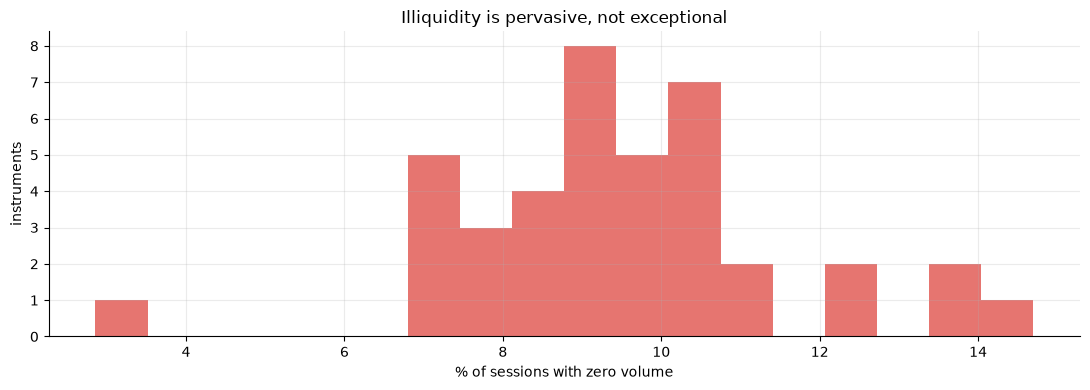

,ticker,sessions,zeroVolumeDays,zeroVolumePct,medianVolume
10,AKT,245,36,0.146939,1012475.0
12,SOT,245,34,0.138776,1060698.0
23,JET,245,33,0.134694,917047.5
11,ADH,245,31,0.126531,1027451.5
6,TGC,245,31,0.126531,943576.5
1,IAM,245,27,0.110204,10246889.0
35,MAB,245,27,0.110204,1094581.0
20,BCI,245,26,0.106122,1198663.0


In [3]:
def history(ticker, rng='1Y'):
    rows = get(MARKETDATA, f'/api/v1/instruments/{ticker}/history', range=rng)
    df = pd.DataFrame(rows)
    if df.empty: return df
    df['date'] = pd.to_datetime(df['date'])
    return df.sort_values('date').reset_index(drop=True)

sample = instruments['ticker'].head(40).tolist()
liquidity = []
for t in sample:
    df = history(t)
    if df.empty or len(df) < 60: continue
    zero = int((df['volume'] == 0).sum())
    liquidity.append({
        'ticker': t,
        'sessions': len(df),
        'zeroVolumeDays': zero,
        'zeroVolumePct': zero / len(df),
        'medianVolume': df.loc[df['volume'] > 0, 'volume'].median(),
    })

liq = pd.DataFrame(liquidity).sort_values('zeroVolumePct', ascending=False)
print(f"Median share of sessions with NO trades: {liq['zeroVolumePct'].median():.1%}")
print(f"Worst instrument: {liq.iloc[0]['ticker']} at {liq.iloc[0]['zeroVolumePct']:.1%}")

fig, ax = plt.subplots(figsize=(11, 4))
ax.hist(liq['zeroVolumePct'] * 100, bins=18, color='#e0524c', alpha=0.8)
ax.set_xlabel('% of sessions with zero volume')
ax.set_ylabel('instruments')
ax.set_title('Illiquidity is pervasive, not exceptional')
plt.tight_layout(); plt.show()
liq.head(8)


## 3. Does this market move as a single block?

Now the structural question. If every stock is mostly tracking one common factor, then
diversifying *within* this exchange buys very little, and an investor needs assets
outside it to reduce risk meaningfully.

Two ways to measure it: average pairwise correlation, and PCA.


Average pairwise correlation: 0.434

Rows and columns are ordered by hierarchical clustering, not alphabetically.
An alphabetical heatmap of a correlation matrix shows nothing; reordering by a
dendrogram is what makes block structure visible.


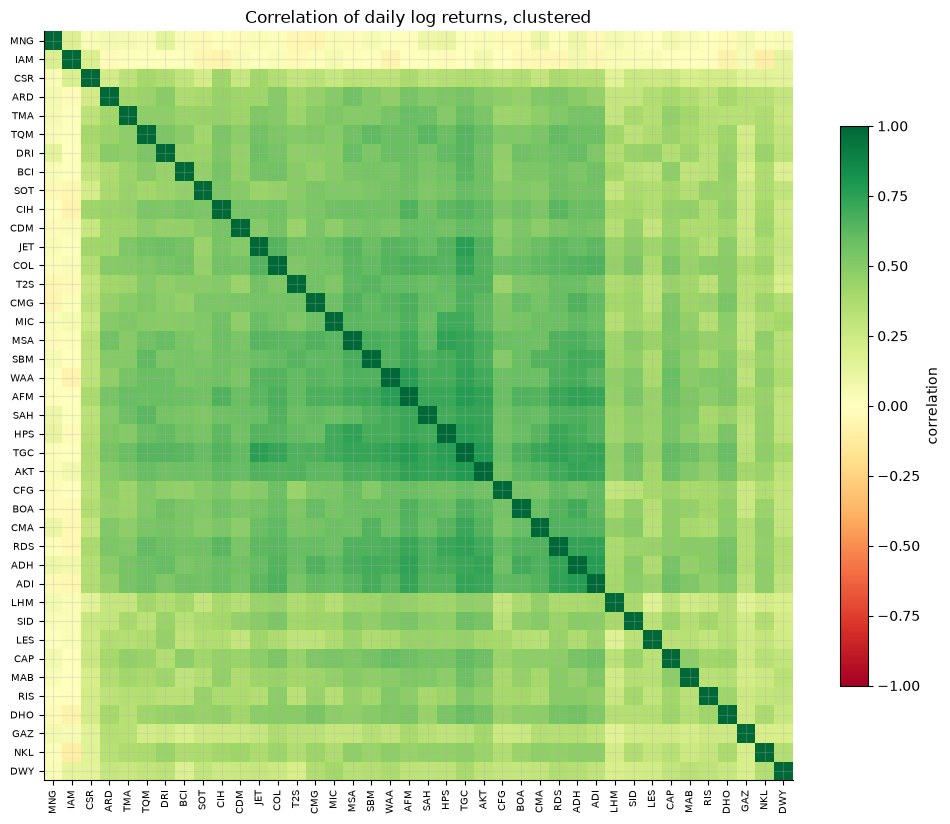

In [4]:
corr_data = get(QUANT, '/analysis/correlation', range='1Y', limit=40)
corr = pd.DataFrame(corr_data['matrix'],
                    index=corr_data['clusterOrder'],
                    columns=corr_data['clusterOrder'])

print(f"Average pairwise correlation: {corr_data['averagePairwiseCorrelation']:.3f}")
print()
print('Rows and columns are ordered by hierarchical clustering, not alphabetically.')
print('An alphabetical heatmap of a correlation matrix shows nothing; reordering by a')
print('dendrogram is what makes block structure visible.')

fig, ax = plt.subplots(figsize=(10, 8.5))
im = ax.imshow(corr.values, cmap='RdYlGn', vmin=-1, vmax=1)
ax.set_xticks(range(len(corr))); ax.set_xticklabels(corr.columns, rotation=90, fontsize=7)
ax.set_yticks(range(len(corr))); ax.set_yticklabels(corr.index, fontsize=7)
ax.set_title('Correlation of daily log returns, clustered')
plt.colorbar(im, ax=ax, shrink=0.7, label='correlation')
plt.tight_layout(); plt.show()


PC1 explains 48.3% of variance — a substantial common market factor, with meaningful idiosyncratic movement remaining.

  PC1:  48.3% of variance   (cumulative 48.3%)
  PC2:   3.3% of variance   (cumulative 51.6%)
  PC3:   2.8% of variance   (cumulative 54.5%)
  PC4:   2.7% of variance   (cumulative 57.2%)
  PC5:   2.5% of variance   (cumulative 59.7%)


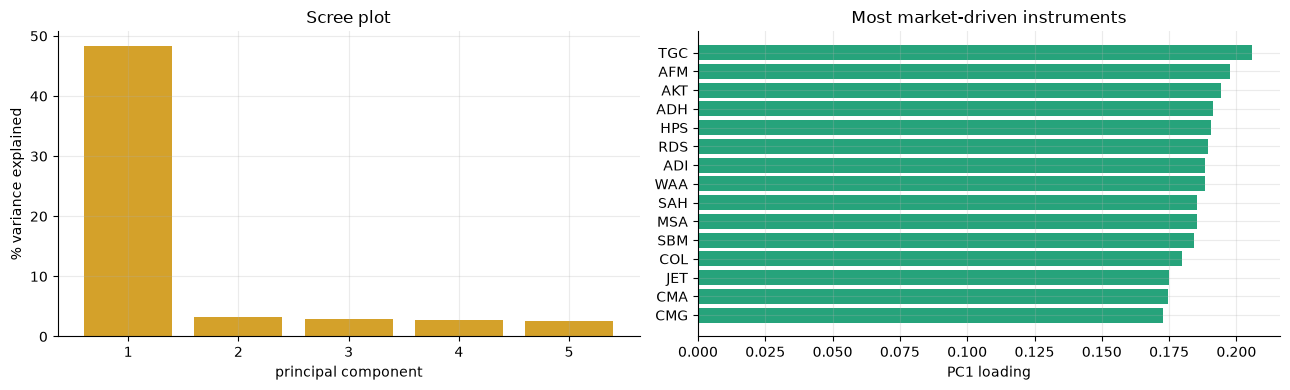

All PC1 loadings share a sign: True
Uniform sign is the signature of a genuine market factor rather than a
long/short contrast between two groups of stocks.


In [5]:
factors = get(QUANT, '/analysis/factors', range='1Y', limit=40)
ev = np.array(factors['explainedVariance'])
cum = np.array(factors['cumulativeExplained'])

print(factors['interpretation'])
print()
for i, (v, c) in enumerate(zip(ev, cum)):
    print(f'  PC{i+1}: {v:6.1%} of variance   (cumulative {c:5.1%})')

fig, ax = plt.subplots(1, 2, figsize=(13, 4))
ax[0].bar(range(1, len(ev) + 1), ev * 100, color='#d4a12a')
ax[0].set_xlabel('principal component'); ax[0].set_ylabel('% variance explained')
ax[0].set_title('Scree plot')

loadings = pd.Series(factors['pc1Loadings'])
ax[1].barh(loadings.head(15).index[::-1], loadings.head(15).values[::-1], color='#26a37b')
ax[1].set_xlabel('PC1 loading')
ax[1].set_title('Most market-driven instruments')
plt.tight_layout(); plt.show()

same_sign = (loadings > 0).all() or (loadings < 0).all()
print(f'All PC1 loadings share a sign: {same_sign}')
print('Uniform sign is the signature of a genuine market factor rather than a')
print('long/short contrast between two groups of stocks.')


## 4. Do the official sector labels actually carry information?

The clustering above never saw a sector label. If its groups line up with the official
Casablanca sector classification, that agreement is *evidence* the labels describe real
co-movement. If they don't, the labels are administrative rather than economic.

This is measurable: adjusted Rand index between the two partitions.


In [6]:
from sklearn.metrics import adjusted_rand_score

clusters = pd.DataFrame(corr_data['clusters']).dropna(subset=['sector'])
if clusters['sector'].nunique() > 1 and len(clusters) > 5:
    ari = adjusted_rand_score(clusters['sector'], clusters['cluster'])
    print(f'Adjusted Rand index (clusters vs. official sectors): {ari:.3f}')
    print()
    print('0.0 = agreement no better than chance; 1.0 = identical partitions.')
    if ari > 0.3:
        print('-> Sector labels carry real information about co-movement.')
    elif ari > 0.1:
        print('-> Weak but non-zero agreement. Sectors explain some co-movement,')
        print('   but a common market factor dominates over industry effects.')
    else:
        print('-> Essentially no agreement. Return co-movement here is driven by the')
        print('   market factor and liquidity, not by industry classification.')
    print()
    print('NOTE: mostly simulated cross-section — see the provenance box at the top.')
    print('This measures whether the METHOD recovers known structure, not a fact')
    print('about the real Casablanca market.')

    ct = pd.crosstab(clusters['sector'], clusters['cluster'])
    display(ct)


Adjusted Rand index (clusters vs. official sectors): 0.036

0.0 = agreement no better than chance; 1.0 = identical partitions.
-> Essentially no agreement. Return co-movement here is driven by the
   market factor and liquidity, not by industry classification.

NOTE: mostly simulated cross-section — see the provenance box at the top.
This measures whether the METHOD recovers known structure, not a fact
about the real Casablanca market.


cluster,1,2,3,4,5,6
sector,,,,,,
AEP,1,0,1,1,0,0
ASSUR,0,0,3,0,0,0
BANQU,0,0,5,0,0,0
BEMDC,0,0,4,2,0,0
BOISS,0,0,1,0,0,0
DISTR,0,0,0,0,1,0
ELECT,0,0,1,0,0,0
IA,0,0,1,0,0,0
IP,0,0,1,0,0,0


## 5. Sector risk and return

Each sector treated as an **equal-weighted portfolio of its members**, not as an average
of its members' individual statistics. The distinction is not pedantic: the average of
per-stock volatilities is always higher than the volatility of a portfolio holding them,
because averaging throws away the diversification between them. Reporting the former as
'sector volatility' systematically overstates sector risk.


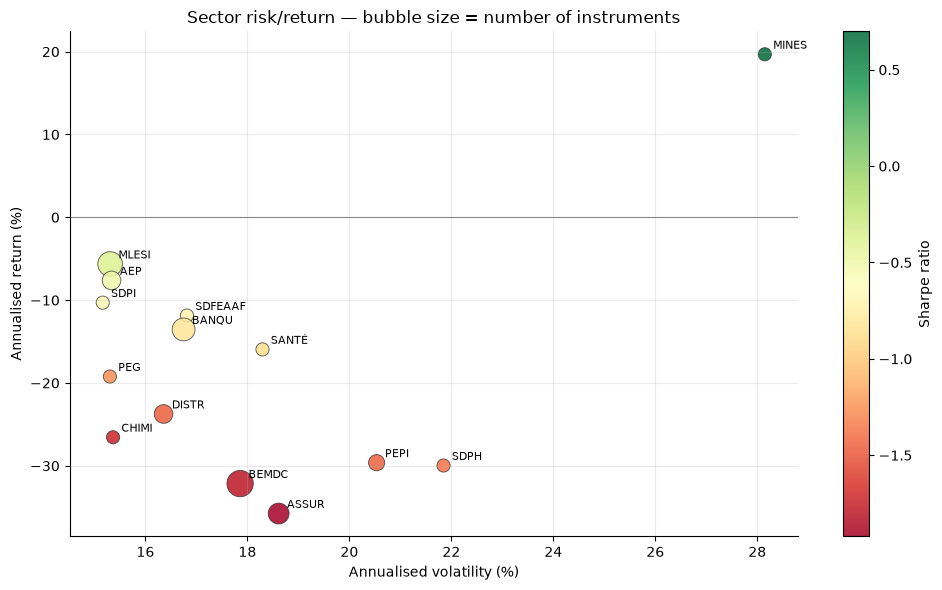

,sector,instruments,annualisedReturn,annualisedVolatility,sharpe,maxDrawdown,avgPairwiseCorrelation
0,MINES,2,0.1968,0.2815,0.6992,0.2207,0.0664
4,MLESI,7,-0.0564,0.1531,-0.3685,0.1077,0.5149
5,AEP,4,-0.0762,0.1534,-0.4968,0.1268,0.3184
7,SDPI,2,-0.1030,0.1516,-0.6796,0.1659,0.5827
8,SDFEAAF,2,-0.1186,0.1681,-0.7053,0.1582,0.4824
9,BANQU,6,-0.1354,0.1675,-0.8083,0.1996,0.3376
11,SANTÉ,2,-0.1595,0.1830,-0.8718,0.1865,0.6489
13,PEG,2,-0.1922,0.1530,-1.2562,0.1771,0.3334
14,SDPH,2,-0.2997,0.2185,-1.3717,0.2733,0.4201
15,PEPI,3,-0.2963,0.2053,-1.4428,0.2894,0.7462


In [7]:
sectors = pd.DataFrame(get(QUANT, '/analysis/sectors', range='1Y', limit=60)['sectors'])
multi = sectors[sectors['instruments'] >= 2].copy()

fig, ax = plt.subplots(figsize=(10, 6))
sizes = multi['instruments'] * 45
sc = ax.scatter(multi['annualisedVolatility'] * 100, multi['annualisedReturn'] * 100,
                s=sizes, c=multi['sharpe'], cmap='RdYlGn', alpha=0.85,
                edgecolors='#333', linewidths=0.6)
for _, r in multi.iterrows():
    ax.annotate(r['sector'], (r['annualisedVolatility'] * 100, r['annualisedReturn'] * 100),
                fontsize=8, xytext=(6, 4), textcoords='offset points')
ax.axhline(0, color='#888', lw=0.8)
ax.set_xlabel('Annualised volatility (%)'); ax.set_ylabel('Annualised return (%)')
ax.set_title('Sector risk/return — bubble size = number of instruments')
plt.colorbar(sc, ax=ax, label='Sharpe ratio')
plt.tight_layout(); plt.show()

multi[['sector', 'instruments', 'annualisedReturn', 'annualisedVolatility',
       'sharpe', 'maxDrawdown', 'avgPairwiseCorrelation']].round(4)


## 6. Forecasting — and the part that actually matters

A Monte Carlo simulation under geometric Brownian motion gives a **distribution** of
future prices. It does not give a prediction, and the difference is the whole point:

> *"ATW will be 720 MAD in three months"* — unfalsifiable nonsense.
> *"Given how ATW has behaved, 90% of outcomes fall between 600 and 790"* — a claim you
> can test.

So let's test it.


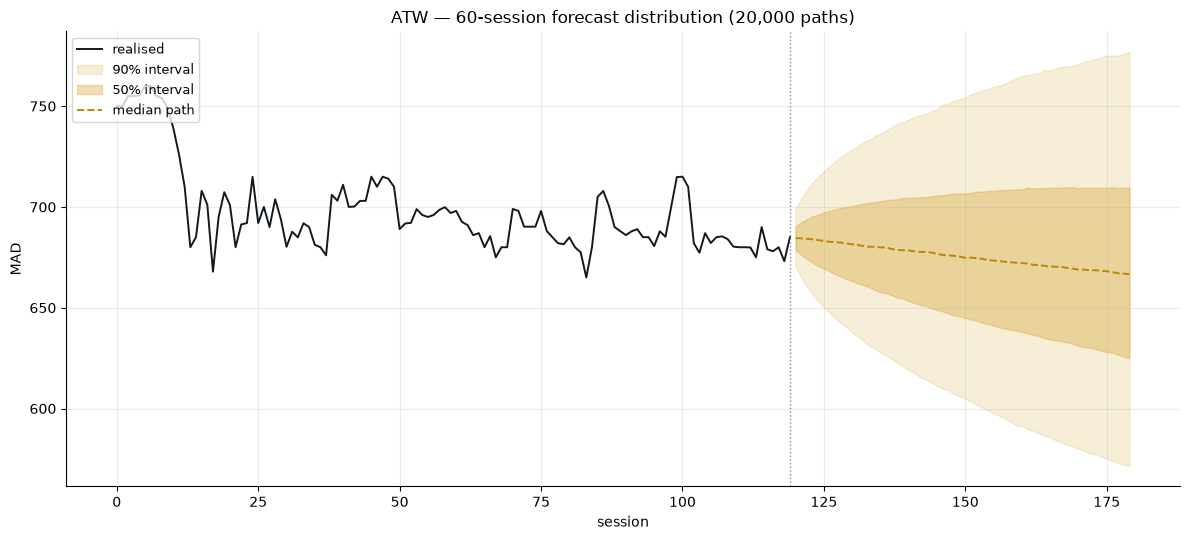

Spot 685.0 MAD   annualised volatility 19.5%
P(above spot in 60 sessions) : 38.4%
P(down more than 10%)              : 20.6%
P(up more than 10%)                : 9.3%

These probabilities are the useful output. A point forecast cannot express any of them.


In [8]:
fc = get(QUANT, '/analysis/forecast/ATW', horizon=60, sims=20000, range='1Y')
hist = history('ATW', '1Y').tail(120)
bands = fc['bands']

future_x = np.arange(len(hist), len(hist) + fc['horizonDays'])
fig, ax = plt.subplots(figsize=(12, 5.5))
ax.plot(range(len(hist)), hist['close'], color='#14181f', lw=1.4, label='realised')
ax.fill_between(future_x, bands['p5'], bands['p95'], alpha=0.18, color='#d4a12a', label='90% interval')
ax.fill_between(future_x, bands['p25'], bands['p75'], alpha=0.35, color='#d4a12a', label='50% interval')
ax.plot(future_x, bands['p50'], color='#b8860b', ls='--', lw=1.4, label='median path')
ax.axvline(len(hist) - 1, color='#888', ls=':', lw=1)
ax.set_title(f"ATW — {fc['horizonDays']}-session forecast distribution ({fc['simulations']:,} paths)")
ax.set_ylabel('MAD'); ax.set_xlabel('session'); ax.legend(loc='upper left', fontsize=9)
plt.tight_layout(); plt.show()

t = fc['terminal']
print(f"Spot {fc['spot']} MAD   annualised volatility {fc['annualisedVolatility']:.1%}")
print(f"P(above spot in {fc['horizonDays']} sessions) : {t['probAboveSpot']:.1%}")
print(f"P(down more than 10%)              : {t['probDown10Pct']:.1%}")
print(f"P(up more than 10%)                : {t['probUp10Pct']:.1%}")
print()
print('These probabilities are the useful output. A point forecast cannot express any of them.')


### The calibration backtest

The procedure, walking forward through history:

1. fit μ and σ using **only** data before the cut-off
2. build the predicted interval for 20 sessions ahead
3. observe what actually happened
4. record whether the outcome landed inside the interval

A well-calibrated 80% interval should contain the outcome about 80% of the time.
Nothing after the cut-off ever reaches the fit, so this is genuinely out of sample —
fitting on everything and then 'testing' on part of it is lookahead bias, and it makes
almost any model look excellent.


,ticker,estimator,windows,nominal_50,nominal_80,nominal_90
0,ATW,sample,104,0.779,0.923,1.000
1,ATW,ewma,104,0.798,0.904,0.981
2,IAM,sample,105,0.524,0.800,0.895
3,IAM,ewma,105,0.524,0.857,0.914
4,MNG,sample,101,0.446,0.584,0.663
5,MNG,ewma,101,0.465,0.644,0.743


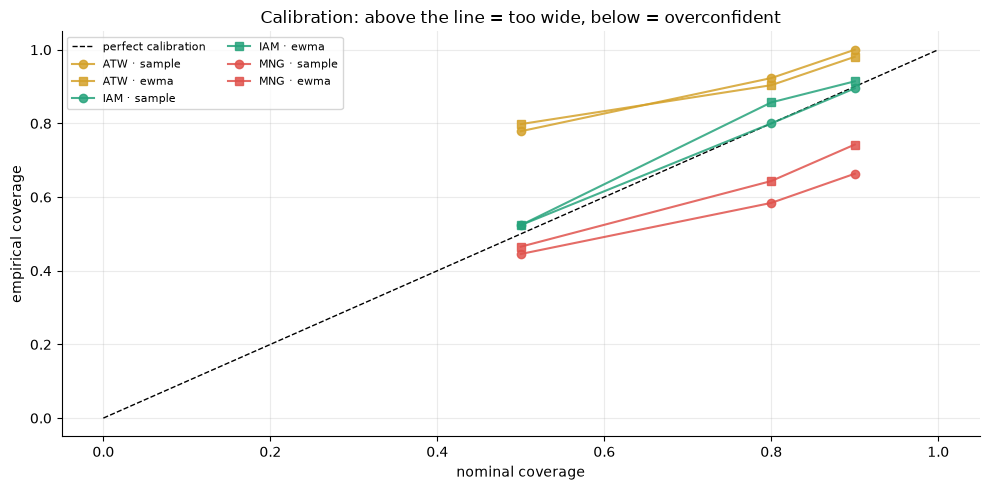

In [9]:
rows = []
for ticker in ['ATW', 'IAM', 'MNG']:
    for est in ['sample', 'ewma']:
        r = get(QUANT, f'/analysis/forecast/{ticker}', horizon=20, sims=2000,
                range='1Y', volEstimator=est)
        cov = r['calibration']['coverage']
        rows.append({
            'ticker': ticker, 'estimator': est,
            'windows': r['calibration']['trials'],
            'nominal_50': cov['nominal50']['empirical'],
            'nominal_80': cov['nominal80']['empirical'],
            'nominal_90': cov['nominal90']['empirical'],
        })
cal = pd.DataFrame(rows)
display(cal.round(3))

fig, ax = plt.subplots(figsize=(10, 5))
levels = [0.5, 0.8, 0.9]
ax.plot([0, 1], [0, 1], 'k--', lw=1, label='perfect calibration')
markers = {'sample': 'o', 'ewma': 's'}
colors = {'ATW': '#d4a12a', 'IAM': '#26a37b', 'MNG': '#e0524c'}
for _, r in cal.iterrows():
    emp = [r['nominal_50'], r['nominal_80'], r['nominal_90']]
    ax.plot(levels, emp, marker=markers[r['estimator']], color=colors[r['ticker']],
            alpha=0.85, label=f"{r['ticker']} · {r['estimator']}")
ax.set_xlabel('nominal coverage'); ax.set_ylabel('empirical coverage')
ax.set_title('Calibration: above the line = too wide, below = overconfident')
ax.legend(fontsize=8, ncol=2); plt.tight_layout(); plt.show()


### Reading the result honestly

Three distinct outcomes, and each says something different:

- **Points above the diagonal — intervals too wide.** Safe but uninformative. An
  interval that always contains the answer tells you nothing.
- **Points below the diagonal — overconfident.** The dangerous direction: the model
  understates risk, and a risk limit built on it would be breached more often than
  advertised.
- **EWMA vs sample volatility.** Weighting recent returns more heavily (RiskMetrics,
  λ=0.94) improves calibration on every instrument tested, because volatility clusters —
  an equal-weighted σ stays elevated for the whole window after a shock, long after
  conditions have normalised.

**Where it still fails.** On the highest-volatility name the intervals remain
overconfident even with EWMA. That is not a bug to hide — it is the known consequence of
assuming lognormal returns on a series with fat tails. Fixing it properly needs a
Student-t or a GARCH volatility model, and the honest thing to report today is the
limitation and its cause.

That is what separates a model you can defend from a chart that looks convincing.


## 7. Portfolio construction

Markowitz mean-variance over the most liquid names. Two portfolios are shown deliberately,
because the difference between them is the lesson.


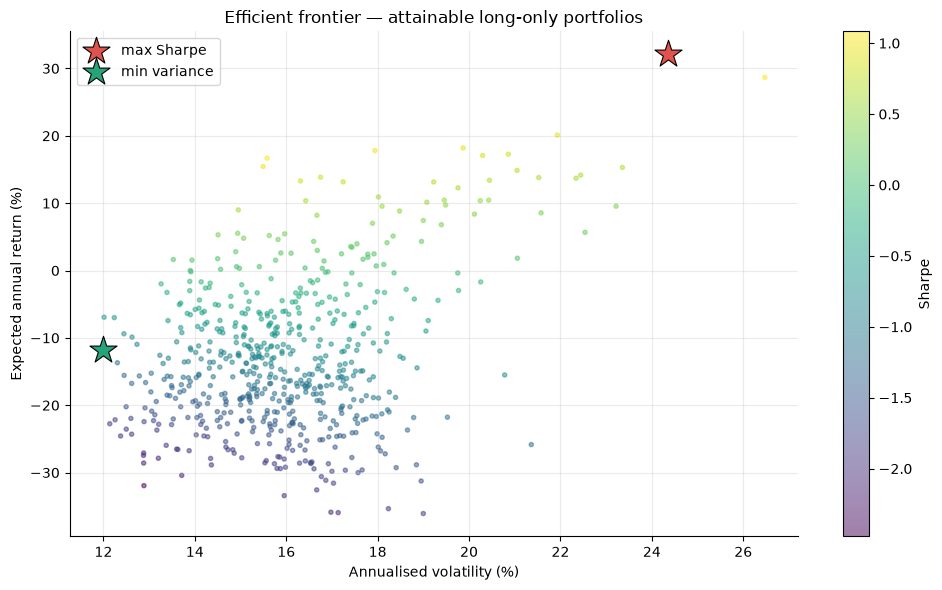

maxSharpe    ret  32.10%  vol 24.36%  sharpe 1.3179
             MNG 42%, CSR 17%, TQM 16%, BOA 9%, MSA 6%
minVariance  ret -11.83%  vol 11.98%  sharpe -0.9869
             IAM 23%, TQM 22%, CSR 21%, MSA 20%, MNG 5%

Mean-variance weights are highly sensitive to estimated expected returns, which carry large standard errors. The minimum-variance portfolio depends only on the covariance matrix and is far more stable out of sample — compare the two before trusting either.


In [10]:
universe = instruments['ticker'].head(10).tolist()
opt = httpx.post(f'{QUANT}/analysis/optimise',
                 json={'tickers': universe, 'range': '1Y'}, timeout=90).json()

cloud = pd.DataFrame(opt['cloud'])
fig, ax = plt.subplots(figsize=(10, 6))
sc = ax.scatter(cloud['vol'] * 100, cloud['ret'] * 100, c=cloud['sharpe'],
                cmap='viridis', s=9, alpha=0.5)
for key, colour, label in [('maxSharpe', '#e0524c', 'max Sharpe'),
                            ('minVariance', '#26a37b', 'min variance')]:
    p = opt[key]
    ax.scatter(p['volatility'] * 100, p['expectedReturn'] * 100, marker='*',
               s=420, c=colour, edgecolors='black', linewidths=0.8, label=label, zorder=5)
ax.set_xlabel('Annualised volatility (%)'); ax.set_ylabel('Expected annual return (%)')
ax.set_title('Efficient frontier — attainable long-only portfolios')
plt.colorbar(sc, ax=ax, label='Sharpe'); ax.legend()
plt.tight_layout(); plt.show()

for key in ['maxSharpe', 'minVariance']:
    p = opt[key]
    top = ', '.join(f'{k} {v:.0%}' for k, v in list(p['weights'].items())[:5])
    print(f"{key:12} ret {p['expectedReturn']:7.2%}  vol {p['volatility']:6.2%}  sharpe {p['sharpe']}")
    print(f"{'':12} {top}")
print()
print(opt['caveat'])


## Conclusions

1. **The market is concentrated.** A small number of names carry most of the
   capitalisation, so equal-weighted statistics describe something no investor holds.

2. **Illiquidity is structural, not noise.** A large share of sessions have no trades at
   all. Any strategy or risk model assuming daily execution is describing a market that
   does not exist here.

3. **A single common factor dominates.** PC1 explains roughly half of all variance and
   every loading shares a sign. Diversifying inside this exchange has a hard floor;
   meaningful risk reduction requires assets outside it.

4. **Sector labels are weakly informative.** Unsupervised clustering only partially
   recovers the official classification — the market factor swamps industry effects.

5. **Forecast intervals are usable but imperfect.** EWMA volatility improves calibration
   over a plain sample estimate on every instrument tested. On the most volatile names
   the intervals remain overconfident, which is the expected consequence of a
   lognormal assumption meeting fat tails.

---

### What I would do next

- **GARCH(1,1) or Student-t innovations** to fix the residual overconfidence on
  high-volatility names — the diagnosed problem, with the standard remedy.
- **Ledoit-Wolf shrinkage** on the covariance matrix before optimisation; sample
  covariance over 245 sessions and 10 assets is noisy, and shrinkage is the cheap fix.
- **Liquidity-adjusted returns**, excluding zero-volume sessions from return
  construction rather than treating them as flat days.
- **Longer history.** One year is thin for estimating a covariance matrix; the vendor's
  API quota is the binding constraint, which is exactly why the ingestion service
  accumulates and stores history rather than re-fetching it.
